## Student exposure and attempts

In [ ]:
# =============================================================================
# Fluency zone: how attempts are distributed across the 144 multiplication facts
# =============================================================================
# Feeds the two heatmaps (attempts / distinct students) over the 12x12 grid.
# One row per ORDERED fact -- '6 X 8' and '8 X 6' are separate rows, because
# Fluency records them separately and the asymmetry is informative.
#
# The .sql carries its defaults in the markers, so it stays runnable on its own.
# If a marker ever disappears this cell fails loudly rather than silently
# querying a different population than the notebook claims.
# =============================================================================
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import LogNorm

# --- parameters -------------------------------------------------------------
YEARS = ["ES_2025"]          # Decision #8   {YEARS}
AGE_MIN, AGE_MAX = 8, 15     # Decision #2   {AGES}  (this app only has 8-11)

HERE = Path.cwd()            # run the notebook from its own folder
ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("databricks_connector.py not found in any parent directory")
    ROOT = ROOT.parent       # repo root -- holds databricks_connector.py and cached_query.py
sys.path.insert(0, str(ROOT))
(HERE / "cache").mkdir(exist_ok=True)
(HERE / "plots").mkdir(exist_ok=True)

from cached_query import cached_query

SQL_PATH = HERE / "queries" / "attempts_by_fact.sql"
CACHE_DIR = HERE / "cache"

sql_raw = SQL_PATH.read_text(encoding="utf-8")

years_sql = ", ".join(f"'{y}'" for y in YEARS)
sql_text, n_y = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})", f"IN ({years_sql})\\1", sql_raw)
assert n_y == 1, f"Expected 1 marker -- {{YEARS}}, found {n_y}"

sql_text, n_a = re.subn(r"BETWEEN \d+ AND \d+(\s*-- \{AGES\})",
                        f"BETWEEN {AGE_MIN} AND {AGE_MAX}\\1", sql_text)
assert n_a == 1, f"Expected 1 marker -- {{AGES}}, found {n_a}"

df = cached_query(SQL_PATH, CACHE_DIR, sql_text=sql_text)   # -> cache/attempts_by_fact__<hash>.parquet

# --- operands, and a check that the grid is really full ---------------------
parts = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)
df["op_a"] = parts[0].astype(int)
df["op_b"] = parts[1].astype(int)

ops = list(range(1, 13))
missing = [(a, b) for a in ops for b in ops
           if not ((df["op_a"] == a) & (df["op_b"] == b)).any()]
assert not df.duplicated(["op_a", "op_b"]).any(), "repeated fact -- pivot would fail"

print(f"Rows: {len(df)} of 144 facts | cache -> {CACHE_DIR.relative_to(ROOT)}/")
print(f"{df['n_attempts'].sum():,} attempts | "
      f"{df['n_students'].max():,} pupils on the most-seen fact")
print(f"attempts per fact: min {df['n_attempts'].min():,} "
      f"(={df.loc[df['n_attempts'].idxmin(), 'operation']}), "
      f"max {df['n_attempts'].max():,} "
      f"(={df.loc[df['n_attempts'].idxmax(), 'operation']})")
if missing:
    print(f"NOT DRILLED (blank cells in the heatmap): {missing}")

# how gathered: f_elementary_fluency_attempts, joined to d_students (historic)
# on student_uuid, academic_year_id in YEARS, operation_type = 'multiplication',
# classroom_course_age in [AGE_MIN, AGE_MAX], both operands 1-12. n_attempts
# counts CARD PRESENTATIONS, not tries (a card can carry two).
# CAVEAT: Leitner scheduling -- a fact a pupil fails comes back, so n_attempts
# mixes "scheduled often" with "failed often". n_students is the cleaner reach
# measure of the two panels.

Rows: 144 of 144 facts | cache -> descriptive\cache/
27,573,185 attempts | 102,373 pupils on the most-seen fact
attempts per fact: min 119,125 (=2 X 2), max 316,283 (=6 X 8)


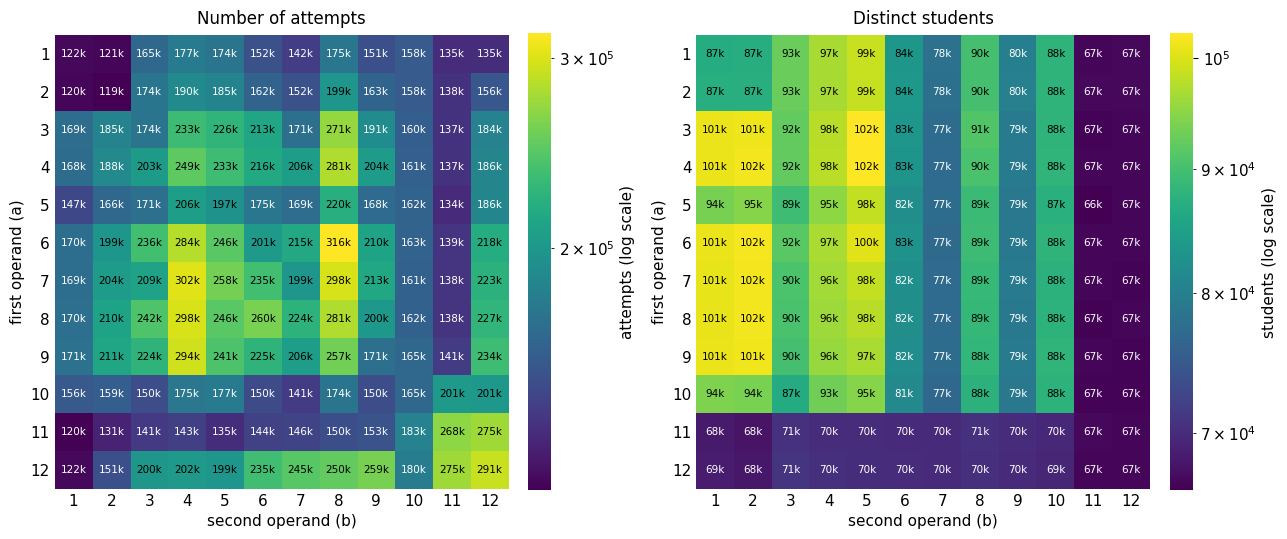

In [ ]:
rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})

# CSV columns: operation ("a X b"), n_attempts, n_students
# thousands="," so counts like "123,456" parse as integers
from pathlib import Path
from databricks_connector import query

# parse operands from "a X b" (capital X, spaces around it)
parts = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)
df["op_a"] = parts[0].astype(int)
df["op_b"] = parts[1].astype(int)

ops = list(range(1, 13))

def grid(col):
    return (df.pivot(index="op_a", columns="op_b", values=col)
              .reindex(index=ops, columns=ops).values.astype(float))

def annotate(ax, mat):
    lo, hi = np.log(np.nanmin(mat)), np.log(np.nanmax(mat))
    for i in range(len(ops)):
        for j in range(len(ops)):
            v = mat[i, j]
            if np.isnan(v):
                continue
            shade = (np.log(v) - lo) / (hi - lo)          # dark cell -> white text
            label = f"{v/1000:.0f}k" if v >= 1000 else f"{v:.0f}"
            ax.text(j, i, label, ha="center", va="center",
                    color="white" if shade < 0.5 else "black", fontsize=7.5)

def style(ax, title):
    ax.set_xticks(range(len(ops))); ax.set_xticklabels(ops)
    ax.set_yticks(range(len(ops))); ax.set_yticklabels(ops)
    ax.set_xlabel("second operand (b)"); ax.set_ylabel("first operand (a)")
    ax.set_title(title, fontsize=12, pad=8)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

M_att = grid("n_attempts")
M_stu = grid("n_students")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.6))

im1 = ax1.imshow(M_att, cmap="viridis", aspect="equal",
                 norm=LogNorm(vmin=np.nanmin(M_att), vmax=np.nanmax(M_att)))
style(ax1, "Number of attempts")
annotate(ax1, M_att)
cb1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cb1.set_label("attempts (log scale)"); cb1.outline.set_visible(False)

im2 = ax2.imshow(M_stu, cmap="viridis", aspect="equal",
                 norm=LogNorm(vmin=np.nanmin(M_stu), vmax=np.nanmax(M_stu)))
style(ax2, "Distinct students")
annotate(ax2, M_stu)
cb2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label("students (log scale)"); cb2.outline.set_visible(False)

fig.tight_layout()
fig.savefig("plots/attempts_students_heatmaps.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/attempts_students_heatmaps.pdf", bbox_inches="tight")
plt.show()

## Difficulty score

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})

# CSV must have columns: operation ("a X b"), mastery_rate, median_attempts
df = pd.read_csv("queries/mastery_by_fact.csv")

# parse operands from "a X b"  (capital X, spaces around it)
parts = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)
df["op_a"] = parts[0].astype(int)
df["op_b"] = parts[1].astype(int)

df["difficulty"] = 1 - df["mastery_rate"]      # 1 - mastery rate
ops = list(range(1, 13))

def grid(col):
    return (df.pivot(index="op_a", columns="op_b", values=col)
              .reindex(index=ops, columns=ops).values)

def annotate(ax, mat, fmt):
    lo, hi = np.nanmin(mat), np.nanmax(mat)
    for i in range(len(ops)):
        for j in range(len(ops)):
            v = mat[i, j]
            if np.isnan(v):
                continue
            shade = (v - lo) / (hi - lo)          # darker cell -> white text
            ax.text(j, i, fmt(v), ha="center", va="center",
                    color="white" if shade > 0.55 else "black", fontsize=7.5)

def style(ax, title):
    ax.set_xticks(range(len(ops))); ax.set_xticklabels(ops)
    ax.set_yticks(range(len(ops))); ax.set_yticklabels(ops)
    ax.set_xlabel("(b)"); ax.set_ylabel("(a)")
    ax.set_title(title, fontsize=12, pad=8)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

M_diff = grid("difficulty")          # dark = hard (high 1 - mastery)
M_att  = grid("median_attempts")     # dark = hard (many attempts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.6))

im1 = ax1.imshow(M_diff, cmap="magma_r", aspect="equal")
style(ax1, "Difficulty")
annotate(ax1, M_diff, lambda v: f"{v:.2f}")
cb1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cb1.set_label("difficulty (higher \u2192 harder)"); cb1.outline.set_visible(False)

im2 = ax2.imshow(M_att, cmap="magma_r", aspect="equal")
style(ax2, "Median attempts to mastery")
annotate(ax2, M_att, lambda v: f"{v:.0f}")
cb2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label("attempts (higher \u2192 harder)"); cb2.outline.set_visible(False)

fig.tight_layout()
fig.savefig("plots/mastery_difficulty_heatmaps.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/mastery_difficulty_heatmaps.pdf", bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'queries/mastery_by_fact.csv'

: 

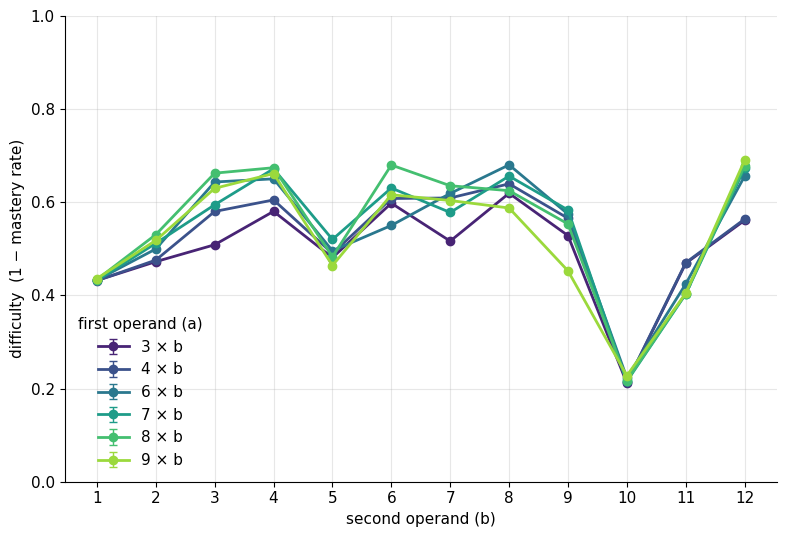

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})

df = pd.read_csv("queries/mastery_by_fact.csv", thousands=",")
parts = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)
df["op_a"] = parts[0].astype(int)
df["op_b"] = parts[1].astype(int)

def wilson(k, n, z=1.96):
    """Wilson score interval for a proportion k/n. Returns (lo, hi)."""
    k, n = np.asarray(k, float), np.asarray(n, float)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    half = (z / denom) * np.sqrt(p*(1-p)/n + z**2 / (4*n**2))
    return centre - half, centre + half

# use the EXACT proportion (not the rounded mastery_rate column) so the point
# always sits inside the Wilson interval; flip onto difficulty (= 1 - p)
p = df["n_mastered"] / df["n_trajectories"]
p_lo, p_hi = wilson(df["n_mastered"], df["n_trajectories"])

df["difficulty"] = 1 - p
df["diff_lo"] = 1 - p_hi          # lower difficulty bound
df["diff_hi"] = 1 - p_lo          # upper difficulty bound

rows = [3, 4, 6, 7, 8, 9]
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(rows)))
fig, ax = plt.subplots(figsize=(8, 5.5))

for a, c in zip(rows, colors):
    sub = df[df["op_a"] == a].sort_values("op_b")
    yerr = np.vstack([sub["difficulty"] - sub["diff_lo"],
                      sub["diff_hi"] - sub["difficulty"]]).clip(min=0)
    ax.errorbar(sub["op_b"], sub["difficulty"], yerr=yerr,
                marker="o", linewidth=2, color=c, capsize=3,
                elinewidth=1, label=f"{a} × b")

ax.set_xlabel("second operand (b)")
ax.set_ylabel("difficulty  (1 \u2212 mastery rate)")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
#ax.set_title("Difficulty vs b (95% Wilson CI), for a = 3, 4, 6, 7", fontsize=12, pad=8)
ax.set_xticks(range(1, 13))
ax.legend(title="first operand (a)", frameon=False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("plots/difficulty_by_b_selected_a.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/difficulty_by_b_selected_a.pdf", bbox_inches="tight")
plt.show()

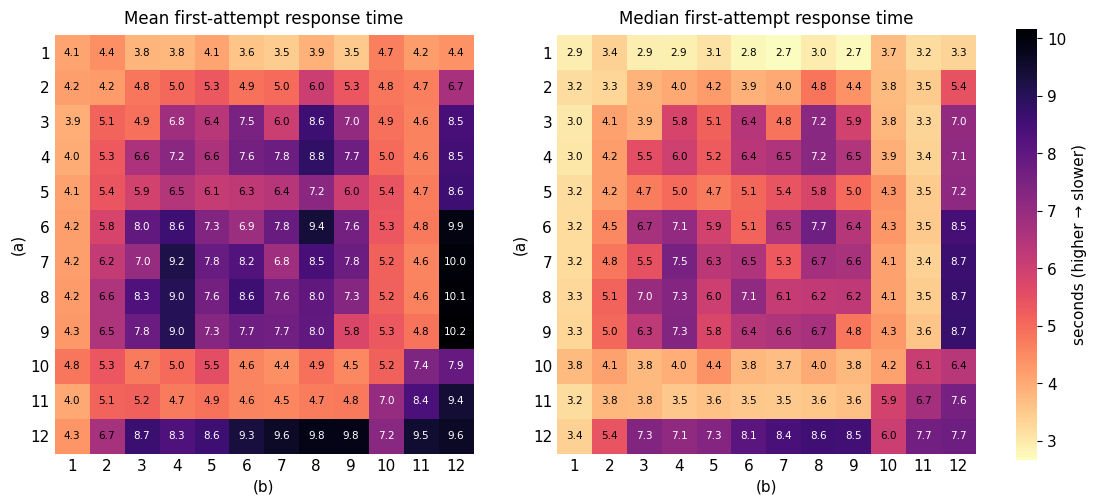

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})

df = pd.read_csv("queries/response_time_by_fact.csv", thousands=",")
df = df[df["operation"].str.contains(r"\sX\s", regex=True)].copy()
parts = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)
df["op_a"] = parts[0].astype(int)
df["op_b"] = parts[1].astype(int)

ops = list(range(1, 13))

def grid(col):
    return (df.pivot(index="op_a", columns="op_b", values=col)
              .reindex(index=ops, columns=ops).values.astype(float))

def annotate(ax, mat, fmt, lo, hi):          # shared lo/hi for consistent text color
    for i in range(len(ops)):
        for j in range(len(ops)):
            v = mat[i, j]
            if np.isnan(v):
                continue
            shade = (v - lo) / (hi - lo)
            ax.text(j, i, fmt(v), ha="center", va="center",
                    color="white" if shade > 0.55 else "black", fontsize=7.5)

def style(ax, title):
    ax.set_xticks(range(len(ops))); ax.set_xticklabels(ops)
    ax.set_yticks(range(len(ops))); ax.set_yticklabels(ops)
    ax.set_xlabel("(b)"); ax.set_ylabel("(a)")
    ax.set_title(title, fontsize=12, pad=8)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

M_mean = grid("mean_rt")
M_med  = grid("median_rt")

# shared color scale across BOTH heatmaps
vmin = np.nanmin([M_mean, M_med])
vmax = np.nanmax([M_mean, M_med])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.6))

im1 = ax1.imshow(M_mean, cmap="magma_r", aspect="equal", vmin=vmin, vmax=vmax)
style(ax1, "Mean first-attempt response time")
annotate(ax1, M_mean, lambda v: f"{v:.1f}", vmin, vmax)

im2 = ax2.imshow(M_med, cmap="magma_r", aspect="equal", vmin=vmin, vmax=vmax)
style(ax2, "Median first-attempt response time")
annotate(ax2, M_med, lambda v: f"{v:.1f}", vmin, vmax)

# one shared colorbar for both panels
cb = fig.colorbar(im2, ax=[ax1, ax2], fraction=0.046, pad=0.04)
cb.set_label("seconds (higher \u2192 slower)"); cb.outline.set_visible(False)

fig.savefig("plots/response_time_heatmaps.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/response_time_heatmaps.pdf", bbox_inches="tight")
plt.show()

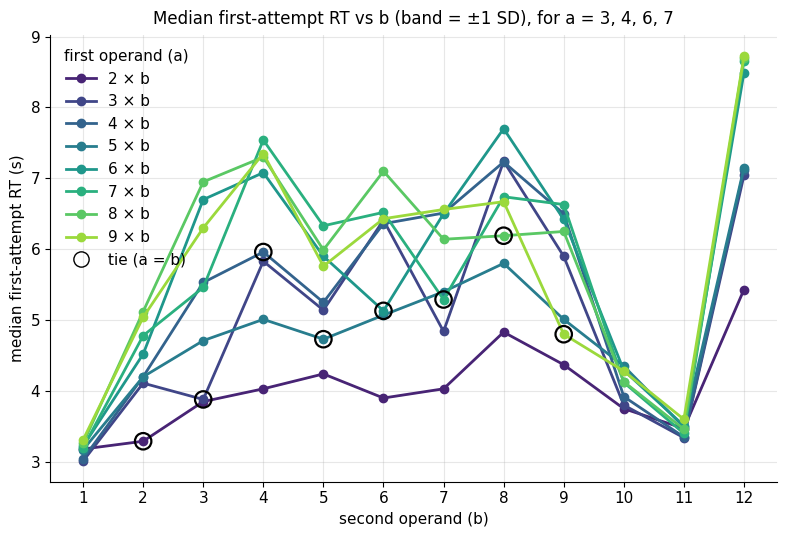

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D

rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})

# columns: operation ("a X b"), median_rt, se_median, ...
df = pd.read_csv("queries/response_time_by_fact.csv", thousands=",")
df = df[df["operation"].str.contains(r"\sX\s", regex=True)].copy()
parts = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)
df["op_a"] = parts[0].astype(int)
df["op_b"] = parts[1].astype(int)

# ±1 student-level SD band (RT analog of the mastery SD used in cell 5)
df["band_lo"] = (df["median_rt"] - df["se_median"]).clip(lower=0)
df["band_hi"] =  df["median_rt"] + df["se_median"]

rows = [2, 3, 4, 5, 6, 7, 8, 9]
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(rows)))
fig, ax = plt.subplots(figsize=(8, 5.5))

for a, c in zip(rows, colors):
    sub = df[df["op_a"] == a].sort_values("op_b")
    ax.fill_between(sub["op_b"], sub["band_lo"], sub["band_hi"],
                    color=c, alpha=0.15, linewidth=0)
    ax.plot(sub["op_b"], sub["median_rt"], marker="o", linewidth=2,
            color=c, label=f"{a} × b")
    tie = sub[sub["op_b"] == a]                       # the single b == a point
    ax.scatter(tie["op_b"], tie["median_rt"],
               s=140, facecolors="none", edgecolors="black",
               linewidths=1.6, zorder=5)

ax.set_xlabel("second operand (b)")
ax.set_ylabel("median first-attempt RT (s)")
ax.set_title("Median first-attempt RT vs b (band = \u00b11 SD), for a = 3, 4, 6, 7",
             fontsize=12, pad=8)
ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], marker="o", markerfacecolor="none",
                      markeredgecolor="black", linestyle="none",
                      markersize=11, label="tie (a = b)"))
ax.legend(handles=handles, title="first operand (a)", frameon=False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("plots/median_rt_by_b_selected_a.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/median_rt_by_b_selected_a.pdf", bbox_inches="tight")
plt.show()

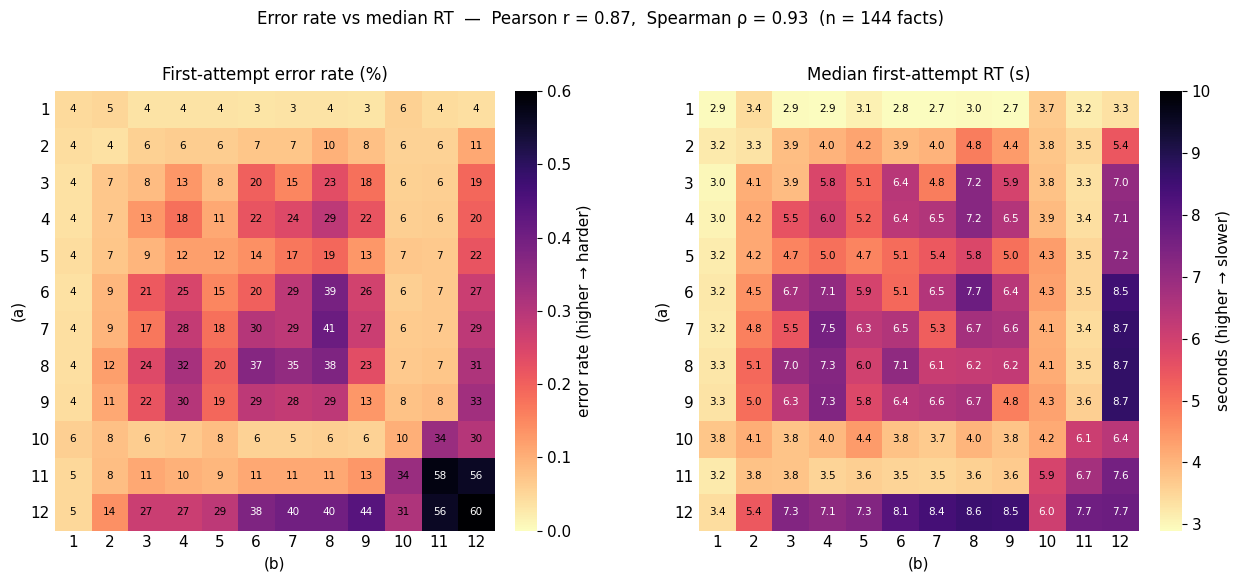

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})

err = pd.read_csv("queries/error_rate_by_fact.csv", thousands=",")
rt  = pd.read_csv("queries/response_time_by_fact.csv", thousands=",")

# merge the two fact-level tables on the operation string
df = err.merge(rt[["operation", "median_rt"]], on="operation", how="inner")
parts = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)
df["op_a"] = parts[0].astype(int)
df["op_b"] = parts[1].astype(int)

ops = list(range(1, 13))

def grid(col):
    return (df.pivot(index="op_a", columns="op_b", values=col)
              .reindex(index=ops, columns=ops).values.astype(float))

def annotate(ax, mat, fmt):
    lo, hi = np.nanmin(mat), np.nanmax(mat)
    for i in range(len(ops)):
        for j in range(len(ops)):
            v = mat[i, j]
            if np.isnan(v):
                continue
            shade = (v - lo) / (hi - lo)
            ax.text(j, i, fmt(v), ha="center", va="center",
                    color="white" if shade > 0.55 else "black", fontsize=7.5)

def style(ax, title):
    ax.set_xticks(range(len(ops))); ax.set_xticklabels(ops)
    ax.set_yticks(range(len(ops))); ax.set_yticklabels(ops)
    ax.set_xlabel("(b)"); ax.set_ylabel("(a)")
    ax.set_title(title, fontsize=12, pad=8)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

M_err = grid("first_attempt_error_rate")
M_rt  = grid("median_rt")

# correlation across facts (both measures present)
pair = df[["first_attempt_error_rate", "median_rt"]].dropna()
r_p = pair.corr().iloc[0, 1]
r_s = pair.corr(method="spearman").iloc[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.6))

im1 = ax1.imshow(M_err, cmap="magma_r", aspect="equal", vmin=0, vmax=np.nanmax(M_err))
style(ax1, "First-attempt error rate (%)")
annotate(ax1, M_err, lambda v: f"{v*100:.0f}")
cb1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cb1.set_label("error rate (higher \u2192 harder)"); cb1.outline.set_visible(False)

im2 = ax2.imshow(M_rt, cmap="magma_r", aspect="equal", vmin=2.9, vmax=10)
style(ax2, "Median first-attempt RT (s)")
annotate(ax2, M_rt, lambda v: f"{v:.1f}")
cb2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label("seconds (higher \u2192 slower)"); cb2.outline.set_visible(False)

fig.suptitle(f"Error rate vs median RT  \u2014  Pearson r = {r_p:.2f},  "
             f"Spearman \u03c1 = {r_s:.2f}  (n = {len(pair)} facts)",
             fontsize=12, y=1.02)

fig.tight_layout()
fig.savefig("plots/error_rate_vs_median_rt_heatmaps.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/error_rate_vs_median_rt_heatmaps.pdf", bbox_inches="tight")
plt.show()

error-rate threshold (median fact): 11.0%
median-RT threshold (median fact):  4.81 s
category
Slow & wrong         70
Fast & accurate      65
Fast but wrong        7
Slow but accurate     2
Name: count, dtype: int64


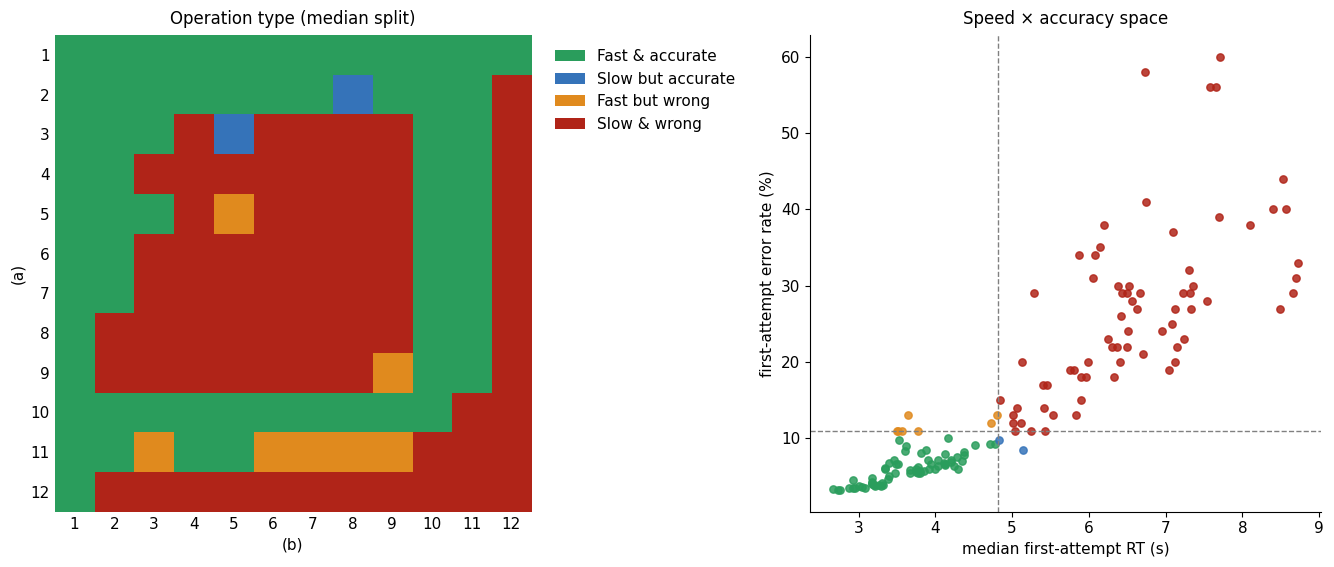


Fast but wrong (7): 11 X 3, 11 X 6, 11 X 7, 11 X 8, 11 X 9, 5 X 5, 9 X 9

Slow but accurate (2): 2 X 8, 3 X 5


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})

err = pd.read_csv("queries/error_rate_by_fact.csv", thousands=",")
rt  = pd.read_csv("queries/response_time_by_fact.csv", thousands=",")
df = err.merge(rt[["operation", "median_rt"]], on="operation")
parts = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)
df["op_a"] = parts[0].astype(int)
df["op_b"] = parts[1].astype(int)

# --- data-driven thresholds: median split on each measure ---
err_thr = df["first_attempt_error_rate"].median()
rt_thr  = df["median_rt"].median()
print(f"error-rate threshold (median fact): {err_thr*100:.1f}%")
print(f"median-RT threshold (median fact):  {rt_thr:.2f} s")

cats = ["Fast & accurate", "Slow but accurate", "Fast but wrong", "Slow & wrong"]
cat_code = {c: i for i, c in enumerate(cats)}

def classify(r):
    slow  = r["median_rt"] >= rt_thr
    wrong = r["first_attempt_error_rate"] >= err_thr
    if not slow and not wrong: return "Fast & accurate"
    if     slow and not wrong: return "Slow but accurate"
    if not slow and     wrong: return "Fast but wrong"
    return "Slow & wrong"

df["category"] = df.apply(classify, axis=1)
print(df["category"].value_counts())

# colors: green / blue / orange / dark red
palette = ["#2a9d5c", "#3573b9", "#e08a1e", "#b02418"]
cmap = ListedColormap(palette)

ops = list(range(1, 13))
M = (df.assign(code=df["category"].map(cat_code))
       .pivot(index="op_a", columns="op_b", values="code")
       .reindex(index=ops, columns=ops).values.astype(float))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.8))

# --- panel 1: categorical grid ---
ax1.imshow(M, cmap=cmap, aspect="equal", vmin=-0.5, vmax=3.5)
ax1.set_xticks(range(12)); ax1.set_xticklabels(ops)
ax1.set_yticks(range(12)); ax1.set_yticklabels(ops)
ax1.set_xlabel("(b)"); ax1.set_ylabel("(a)")
ax1.set_title("Operation type (median split)", fontsize=12, pad=8)
ax1.tick_params(length=0)
for s in ax1.spines.values():
    s.set_visible(False)
ax1.legend(handles=[Patch(facecolor=palette[i], label=c) for i, c in enumerate(cats)],
           loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)

# --- panel 2: scatter with quadrant lines ---
for c in cats:
    sub = df[df["category"] == c]
    ax2.scatter(sub["median_rt"], sub["first_attempt_error_rate"] * 100,
                s=28, color=palette[cat_code[c]], label=c, alpha=0.85)
ax2.axvline(rt_thr, color="grey", lw=1, ls="--")
ax2.axhline(err_thr * 100, color="grey", lw=1, ls="--")
ax2.set_xlabel("median first-attempt RT (s)")
ax2.set_ylabel("first-attempt error rate (%)")
ax2.set_title("Speed \u00d7 accuracy space", fontsize=12, pad=8)
for s in ["top", "right"]:
    ax2.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("plots/operation_typology.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/operation_typology.pdf", bbox_inches="tight")
plt.show()

# lists of facts per category (the interesting off-diagonals first)
for c in ["Fast but wrong", "Slow but accurate"]:
    facts = df.loc[df["category"] == c, "operation"].tolist()
    print(f"\n{c} ({len(facts)}): {', '.join(facts)}")

fit: error% = 6.76 * RT + -18.20


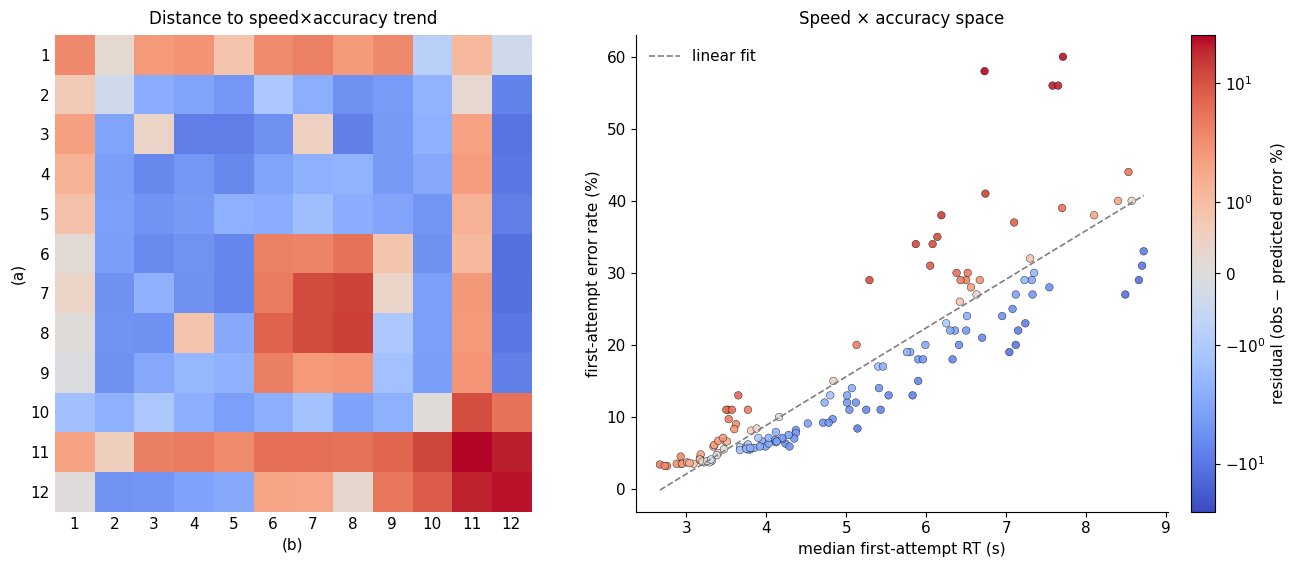


most above trend (slow & wrong / red):
 operation  residual
  11 X 11 30.704119
  12 X 12 26.079642
  11 X 12 22.958400
  12 X 11 22.485223
    8 X 8 14.354340

most below trend (correct & slow / blue):
 operation   residual
   6 X 12 -12.192900
   7 X 12 -11.342044
   3 X 12 -10.391379
   4 X 12  -9.932152
   8 X 12  -9.612431


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import SymLogNorm
from matplotlib.patches import Patch

rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})

err = pd.read_csv("queries/error_rate_by_fact.csv", thousands=",")
rt  = pd.read_csv("queries/response_time_by_fact.csv", thousands=",")
df = err.merge(rt[["operation", "median_rt"]], on="operation")
parts = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)
df["op_a"] = parts[0].astype(int)
df["op_b"] = parts[1].astype(int)

# --- linear fit through the speed x accuracy points ---
x = df["median_rt"].values
y = df["first_attempt_error_rate"].values * 100          # error rate in %
m, b = np.polyfit(x, y, 1)
df["y_pred"]    = m * x + b
df["residual"]  = y - df["y_pred"]                        # +ve = above line, -ve = below
print(f"fit: error% = {m:.2f} * RT + {b:.2f}")

# --- cool-warm color per fact, log-scaled around 0 ---
vmax = np.abs(df["residual"]).max()
linthresh = max(0.5, vmax * 0.05)                        # linear band around 0, then log
norm = SymLogNorm(linthresh=linthresh, vmin=-vmax, vmax=vmax, base=10)
cmap = plt.cm.coolwarm                                    # cool (blue) under, warm (red) over
df["color"] = df["residual"].apply(lambda r: cmap(norm(r)))

ops = list(range(1, 13))
# residual matrix -> same colors on the 12x12 grid
R = (df.pivot(index="op_a", columns="op_b", values="residual")
       .reindex(index=ops, columns=ops).values.astype(float))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.8))

# --- panel 1: 12x12 matrix colored by residual ---
im = ax1.imshow(R, cmap=cmap, norm=norm, aspect="equal")
ax1.set_xticks(range(12)); ax1.set_xticklabels(ops)
ax1.set_yticks(range(12)); ax1.set_yticklabels(ops)
ax1.set_xlabel("(b)"); ax1.set_ylabel("(a)")
ax1.set_title("Distance to speed\u00d7accuracy trend", fontsize=12, pad=8)
ax1.tick_params(length=0)
for s in ax1.spines.values():
    s.set_visible(False)
# ax1.legend(handles=[Patch(facecolor=cmap(0.15), label="blue: correct and slow"),
#                     Patch(facecolor=cmap(0.85), label="red: slow and wrong")],
#            loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)

# --- panel 2: scatter + fitted line, points colored by residual ---
ax2.scatter(x, y, s=30, c=df["residual"], cmap=cmap, norm=norm,
            edgecolor="k", linewidth=0.3, alpha=0.9)
xs = np.linspace(x.min(), x.max(), 100)
ax2.plot(xs, m * xs + b, color="grey", lw=1.2, ls="--", label="linear fit")
ax2.set_xlabel("median first-attempt RT (s)")
ax2.set_ylabel("first-attempt error rate (%)")
ax2.set_title("Speed \u00d7 accuracy space", fontsize=12, pad=8)
ax2.legend(loc="upper left", frameon=False)
for s in ["top", "right"]:
    ax2.spines[s].set_visible(False)
cb = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cb.set_label("residual (obs \u2212 predicted error %)")

fig.tight_layout()
fig.savefig("plots/operation_typology.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/operation_typology.pdf", bbox_inches="tight")
plt.show()

# most over / under the line
over  = df.nlargest(5, "residual")[["operation", "residual"]]
under = df.nsmallest(5, "residual")[["operation", "residual"]]
print("\nmost above trend (slow & wrong / red):\n", over.to_string(index=False))
print("\nmost below trend (correct & slow / blue):\n", under.to_string(index=False))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import SymLogNorm
from matplotlib.patches import Patch
from matplotlib.animation import FuncAnimation, PillowWriter

rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none", "font.size": 11,
                 "text.color": "black", "axes.labelcolor": "black",
                 "xtick.color": "black", "ytick.color": "black"})

df = pd.read_csv("queries/error_rt_by_fact_age.csv", thousands=",")
parts = df["operation"].str.split(r"\s*X\s*", regex=True, expand=True)
df["op_a"] = parts[0].astype(int)
df["op_b"] = parts[1].astype(int)
df["err"] = df["first_attempt_error_rate"] * 100          # tasa de error en %
df = df[df["age"] <= 12].copy()

ages = sorted(df["age"].unique())
ops  = list(range(1, 13))

# --- una sola recta fija a partir de TODOS los puntos agrupados ---
m, b = np.polyfit(df["median_rt"], df["err"], 1)
# POSICIÓN A LO LARGO de la recta: proyectar sobre la dirección (1, m), agrupar
# TODAS las edades y centrar en la proyección MEDIA, de modo que el amarillo (0)
# = posición media a lo largo de la recta.
#   +ve = extremo superior-derecha (rojo),  -ve = extremo inferior-izquierda (verde)
t = (df["median_rt"] + m * df["err"]) / np.hypot(1, m)
df["residual"] = t - t.mean()
print(f"ajuste agrupado: error% = {m:.2f} * TR + {b:.2f}")

# --- escala de color fijada UNA vez sobre todas las edades; simétrica para que el amarillo = media agrupada ---
vmax = np.abs(df["residual"]).max()
linthresh = max(0.1, vmax * 0.05)                         # banda lineal alrededor de 0, luego log
norm = SymLogNorm(linthresh=linthresh, vmin=-vmax, vmax=vmax, base=10)
cmap = plt.cm.RdYlGn_r                                    # verde (extremo bajo) -> amarillo (media) -> rojo (extremo alto)

# rangos de ejes fijos para que nada salte entre fotogramas
rt_lo, rt_hi   = df["median_rt"].min(), df["median_rt"].max()
err_lo, err_hi = df["err"].min(), df["err"].max()
pad = 0.05 * (err_hi - err_lo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 6.0))
fig.subplots_adjust(top=0.86)                             # margen superior para el título de Edad
im = ax1.imshow(np.full((12, 12), np.nan), cmap=cmap, norm=norm, aspect="equal")
cb = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
# cb.set_label("posición a lo largo de la recta (media = 0, bajo \u2212 / alto +)")

def draw(a):
    sub = df[df["age"] == a]

    R = (sub.pivot(index="op_a", columns="op_b", values="residual")
            .reindex(index=ops, columns=ops).values.astype(float))

    ax1.clear(); ax2.clear()

    # panel 1: matriz 12x12
    ax1.imshow(R, cmap=cmap, norm=norm, aspect="equal")
    ax1.set_xticks(range(12)); ax1.set_xticklabels(ops)
    ax1.set_yticks(range(12)); ax1.set_yticklabels(ops)
    ax1.set_xlabel("(b)"); ax1.set_ylabel("(a)")
    ax1.set_title("Posición a lo largo de la tendencia velocidad\u00d7precisión", fontsize=12, pad=8)
    ax1.tick_params(length=0)
    for s in ax1.spines.values():
        s.set_visible(False)
    # ax1.legend(handles=[Patch(facecolor=cmap(0.15), label="verde: extremo inferior-izquierda (rápido y preciso)"),
    #                     Patch(facecolor=cmap(0.85), label="rojo: extremo superior-derecha (lento e incorrecto)")],
            #    loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)

    # panel 2: dispersión + recta agrupada fija
    ax2.scatter(sub["median_rt"], sub["err"], s=30, c=sub["residual"],
                cmap=cmap, norm=norm, edgecolor="k", linewidth=0.3, alpha=0.9)
    xs = np.linspace(rt_lo, rt_hi, 100)
    ax2.plot(xs, m * xs + b, color="grey", lw=1.2, ls="--", label="ajuste agrupado")
    ax2.set_xlim(rt_lo, rt_hi)
    ax2.set_ylim(err_lo - pad, err_hi + pad)
    ax2.set_xlabel("mediana TR primer intento (s)")
    ax2.set_ylabel("tasa de error primer intento (%)")
    ax2.set_title("Espacio velocidad \u00d7 precisión", fontsize=12, pad=8)
    ax2.legend(loc="upper left", frameon=False)
    for s in ["top", "right"]:
        ax2.spines[s].set_visible(False)

    fig.suptitle(f"Edad {a}", fontsize=15, y=0.97)

anim = FuncAnimation(fig, draw, frames=ages, interval=800)
anim.save("plots/AAAAoperation_typology_by_age.gif", writer=PillowWriter(fps=1.5), dpi=120)
plt.close(fig)
print(f"guardado plots/AAAAoperation_typology_by_age.gif ({len(ages)} fotogramas: edades {ages[0]}-{ages[-1]})")


pooled fit: error% = 4.21 * RT + -8.47
saved plots/AAAAoperation_typology_by_age.gif (7 frames: ages 6-12)


## Dades descrptives

In [ ]:
import pandas as pd, numpy as np
df = pd.read_csv("queries/error_rt_by_fact_age.csv", thousands=",")
df = df[df["age"].between(8, 12)]                       # descarta 6-7 (mostra ínfima)
df["errors"] = df["first_attempt_error_rate"] * df["n_attempts"]
g = (df.groupby("age")
       .apply(lambda x: pd.Series({
           "n": x["n_attempts"].sum(),
           "err_pct": 100 * x["errors"].sum() / x["n_attempts"].sum(),
           "rt": np.average(x["median_rt"], weights=x["n_attempts"]),
       }), include_groups=False)
       .reset_index())
g["d_err_pp"]  = g["err_pct"].diff()                    # negatiu = menys errors
g["d_err_rel"] = 100 * g["err_pct"].diff() / g["err_pct"].shift()
g["d_rt_s"]    = g["rt"].diff()                          # negatiu = més ràpid
g["d_rt_rel"]  = 100 * g["rt"].diff() / g["rt"].shift()
print(g.round(2).to_string(index=False))

 age          n  err_pct   rt  d_err_pp  d_err_rel  d_rt_s  d_rt_rel
   8  6944802.0    19.41 7.83       NaN        NaN     NaN       NaN
   9 17474686.0    16.88 6.56     -2.53     -13.05   -1.26    -16.13
  10 16418734.0    17.67 5.52      0.79       4.67   -1.04    -15.85
  11 16838872.0    15.36 4.95     -2.31     -13.05   -0.57    -10.38
  12   527679.0     9.18 3.90     -6.18     -40.24   -1.05    -21.13


In [ ]:
import numpy as np, pandas as pd

df = pd.read_csv("queries/student_rt_by_age.csv", thousands=",")
df = df[df["age"].between(8, 12)]
df["err_pct"] = df["err_rate"] * 100
ages = sorted(df["age"].unique())

summ = (df.groupby("age")
          .agg(n=("student_uuid", "size"),
               rt_q1=("median_rt", lambda s: s.quantile(.25)),
               rt_med=("median_rt", "median"),
               rt_q3=("median_rt", lambda s: s.quantile(.75)),
               err_q1=("err_pct", lambda s: s.quantile(.25)),
               err_med=("err_pct", "median"),
               err_q3=("err_pct", lambda s: s.quantile(.75)))
          .reset_index())
print(summ.round(2).to_string(index=False))

med = dict(zip(summ["age"], summ["rt_med"]))
q1  = dict(zip(summ["age"], summ["rt_q1"]))
q3  = dict(zip(summ["age"], summ["rt_q3"]))

print("\n--- solapament de velocitat entre cursos ---")
for ay in ages:
    for ao in ages:
        if ao > ay:
            pct = (df[df.age == ay]["median_rt"] < med[ao]).mean() * 100
            if pct >= 20:
                print(f"El {pct:.0f}% dels alumnes de {ay} anys responen mes rapid "
                      f"que la mediana dels de {ao} anys")

print("\n--- equivalencia per quartils (el mes cridaner) ---")
best = None
for ay in ages:
    for ao in ages:
        if ao > ay and q1[ay] >= q3[ao] and (best is None or ao - ay > best[1] - best[0]):
            best = (ay, ao)
if best:
    ay, ao = best
    print(f"El 25% mes rapid dels de {ay} anys (<= {q1[ay]:.1f}s) va tan rapid o mes "
          f"que el 25% mes lent dels de {ao} anys (>= {q3[ao]:.1f}s) — {ao-ay} cursos de diferencia")

 age     n  rt_q1  rt_med  rt_q3  err_q1  err_med  err_q3
   8 48002   6.05    7.71   9.67    10.0     10.0    20.0
   9 58273   5.27    6.48   8.14    10.0     10.0    20.0
  10 52868   4.41    5.32   6.66    10.0     10.0    20.0
  11 44811   3.90    4.76   5.82     0.0     10.0    20.0
  12  3407   2.84    3.47   4.36     0.0      0.0    10.0

--- solapament de velocitat entre cursos ---
El 31% dels alumnes de 8 anys responen mes rapid que la mediana dels de 9 anys
El 26% dels alumnes de 9 anys responen mes rapid que la mediana dels de 10 anys
El 34% dels alumnes de 10 anys responen mes rapid que la mediana dels de 11 anys

--- equivalencia per quartils (el mes cridaner) ---
El 25% mes rapid dels de 8 anys (<= 6.0s) va tan rapid o mes que el 25% mes lent dels de 12 anys (>= 4.4s) — 4 cursos de diferencia


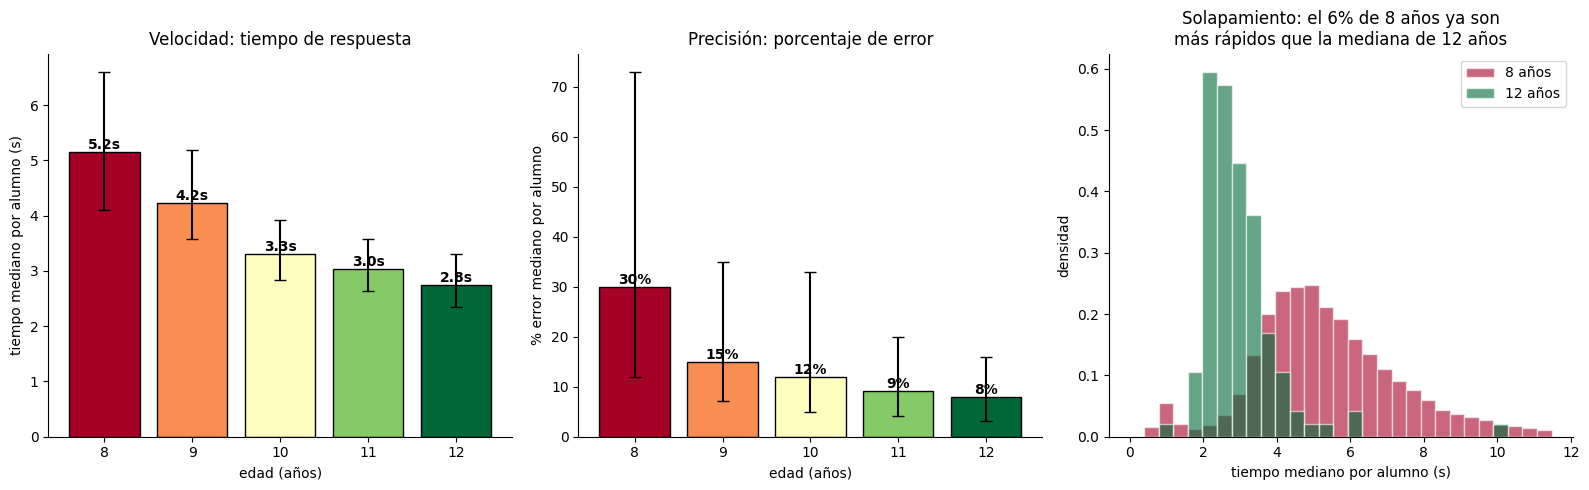

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("queries/student_rt_by_age.csv", thousands=",")
df = df[df["age"].between(8, 12)]
df["err_pct"] = df["err_rate"] * 100
ages = sorted(df["age"].unique())
cmap = plt.cm.RdYlGn
cols = [cmap((a - min(ages)) / (max(ages) - min(ages))) for a in ages]   # mayor = verde

summ = (df.groupby("age")
          .agg(rt_q1=("median_rt", lambda s: s.quantile(.25)),
               rt_med=("median_rt", "median"),
               rt_q3=("median_rt", lambda s: s.quantile(.75)),
               err_q1=("err_pct", lambda s: s.quantile(.25)),
               err_med=("err_pct", "median"),
               err_q3=("err_pct", lambda s: s.quantile(.75)))
          .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A — velocidad (RT mediana por edad, barras de error = Q1–Q3)
a = axes[0]
yerr = [summ["rt_med"] - summ["rt_q1"], summ["rt_q3"] - summ["rt_med"]]
a.bar(summ["age"], summ["rt_med"], yerr=yerr, color=cols, edgecolor="k", capsize=4)
for x, v in zip(summ["age"], summ["rt_med"]):
    a.text(x, v, f"{v:.1f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
a.set_title("Velocidad: tiempo de respuesta", fontsize=12)
a.set_xlabel("edad (años)"); a.set_ylabel("tiempo mediano por alumno (s)")

# Panel B — precisión (% error mediano por edad, barras de error = Q1–Q3)
b = axes[1]
yerr = [summ["err_med"] - summ["err_q1"], summ["err_q3"] - summ["err_med"]]
b.bar(summ["age"], summ["err_med"], yerr=yerr, color=cols, edgecolor="k", capsize=4)
for x, v in zip(summ["age"], summ["err_med"]):
    b.text(x, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
b.set_title("Precisión: porcentaje de error", fontsize=12)
b.set_xlabel("edad (años)"); b.set_ylabel("% error mediano por alumno")

# Panel C — solapamiento (histograma superpuesto del curso más joven vs. el más mayor)
c = axes[2]
ay, ao = min(ages), max(ages)
bins = np.linspace(0, df["median_rt"].quantile(.99), 30)
c.hist(df[df.age == ay]["median_rt"], bins=bins, color=cmap(0.0), alpha=.6,
       density=True, label=f"{ay} años", edgecolor="white")
c.hist(df[df.age == ao]["median_rt"], bins=bins, color=cmap(1.0), alpha=.6,
       density=True, label=f"{ao} años", edgecolor="white")
pct = (df[df.age == ay]["median_rt"] < summ.set_index("age").loc[ao, "rt_med"]).mean() * 100
c.set_title(f"Solapamiento: el {pct:.0f}% de {ay} años ya son\nmás rápidos que la mediana de {ao} años", fontsize=12)
c.set_xlabel("tiempo mediano por alumno (s)"); c.set_ylabel("densidad"); c.legend()

for ax in axes:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("plots/estadisticas_curso_a_curso.png", dpi=200, bbox_inches="tight")
plt.show()

C:\Users\maria.garcia\AppData\Local\Temp\ipykernel_30276\1285314226.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of min will be keyword-only.
  df = df[(df[["a","b"]].min(1) >= 2) & (df[["a","b"]].max(1) <= 9)]
C:\Users\maria.garcia\AppData\Local\Temp\ipykernel_30276\1285314226.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of max will be keyword-only.
  df = df[(df[["a","b"]].min(1) >= 2) & (df[["a","b"]].max(1) <= 9)]


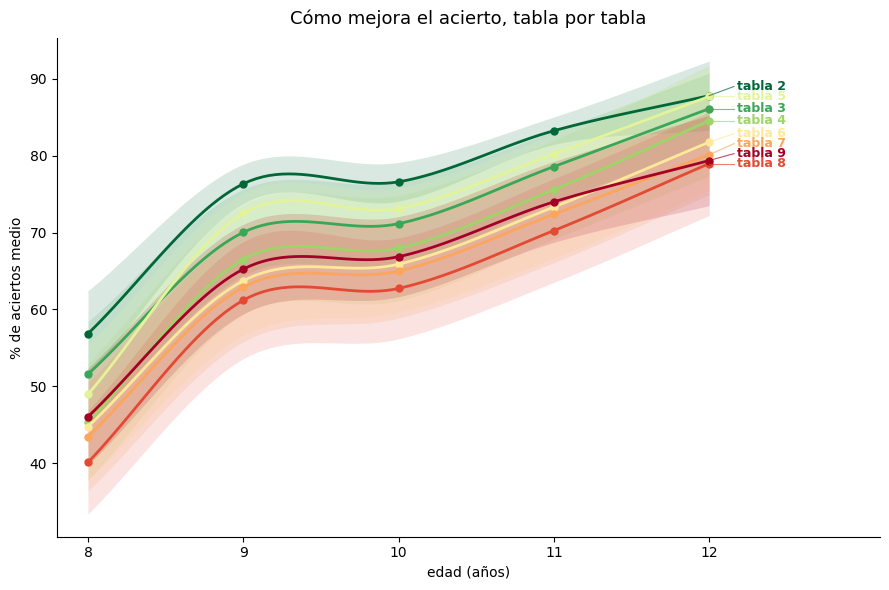

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("queries/acc_by_op_age.csv", thousands=",")
ab = df["operation"].str.extract(r"(\d+)X(\d+)").astype(int)
df["a"], df["b"] = ab[0], ab[1]
df = df[(df[["a","b"]].min(1) >= 2) & (df[["a","b"]].max(1) <= 9)]
df["acc_fact"] = 100 * df["n_correct"] / df["n"]         # % encerts per fet

# "taula del N" = tots els seus múltiples: cada fet compta a la taula de CADA factor
# (2×8 -> taula del 2 i del 8; el 2×2 només un cop)
long = pd.concat([df.assign(table=df["a"]),
                  df[df["a"] != df["b"]].assign(table=df["b"])], ignore_index=True)
long = long[long["table"].between(2, 9)]

g = (long.groupby(["table", "age"])["acc_fact"].agg(mean="mean", sd="std").reset_index())
g["sd"] = g["sd"].fillna(0)

tables = sorted(g["table"].unique()); ages = sorted(g["age"].unique())
cmap = plt.cm.RdYlGn_r
cols = {t: cmap((t - min(tables)) / (max(tables) - min(tables))) for t in tables}  # taula alta = vermell

def smooth(xv, yv, n=24):                    # spline Catmull-Rom (sense scipy)
    xv = np.asarray(xv, float); yv = np.asarray(yv, float)
    X = np.r_[xv[0]-(xv[1]-xv[0]), xv, xv[-1]+(xv[-1]-xv[-2])]
    Y = np.r_[yv[0]-(yv[1]-yv[0]), yv, yv[-1]+(yv[-1]-yv[-2])]
    xs, ys = [], []
    for i in range(1, len(X)-2):
        p0, p1, p2, p3 = Y[i-1], Y[i], Y[i+1], Y[i+2]
        for t in np.linspace(0, 1, n, endpoint=False):
            ys.append(0.5*((2*p1) + (-p0+p2)*t + (2*p0-5*p1+4*p2-p3)*t*t + (-p0+3*p1-3*p2+p3)*t**3))
            xs.append(X[i] + (X[i+1]-X[i])*t)
    xs.append(X[-2]); ys.append(Y[-2])
    return np.array(xs), np.array(ys)

fig, ax = plt.subplots(figsize=(9, 6))
for t in tables:
    d = g[g["table"] == t].sort_values("age")
    xs, mid = smooth(d["age"], d["mean"])
    _,  lo  = smooth(d["age"], d["mean"] - d["sd"])
    _,  hi  = smooth(d["age"], d["mean"] + d["sd"])
    ax.fill_between(xs, lo, hi, color=cols[t], alpha=.15, lw=0)
    ax.plot(xs, mid, color=cols[t], lw=2)
    ax.plot(d["age"], d["mean"], "o", color=cols[t], ms=5)

# etiquetes al final, separades per no solapar-se, amb línia guia
ends = [(t, g[g["table"] == t].sort_values("age")["mean"].iloc[-1]) for t in tables]
ends.sort(key=lambda x: x[1])
ymin = min(e[1] for e in ends); ymax = max(e[1] for e in ends)
gap = max(1.3, (ymax - ymin) * 0.06); ypos = {}; prev = -1e9
for t, y in ends:
    yy = max(y, prev + gap); ypos[t] = yy; prev = yy
x_lab = ages[-1] + 0.18
for t, y in ends:
    ax.plot([ages[-1], x_lab - 0.02], [y, ypos[t]], color=cols[t], lw=.8, alpha=.7)
    ax.text(x_lab, ypos[t], f"tabla {t}", color=cols[t], va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("edad (años)"); ax.set_ylabel("% de aciertos medio")
ax.set_xticks(ages); ax.set_xlim(ages[0] - .2, ages[-1] + 1.1)
ax.set_title("Cómo mejora el acierto, tabla por tabla", fontsize=13, pad=10)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("plots/a998_accuracy_trajectory_by_table.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("queries/acc_by_op_age.csv", thousands=",")
ab = df["operation"].str.extract(r"(\d+)X(\d+)").astype(int)
df["a"], df["b"] = ab[0], ab[1]
df = df[(df[["a","b"]].min(1) >= 2) & (df[["a","b"]].max(1) <= 9)]

# mateixa assignació "per factor" que el gràfic d'evolució per taula
long = pd.concat([df.assign(table=df["a"]),
                  df[df["a"] != df["b"]].assign(table=df["b"])], ignore_index=True)
long = long[long["table"].between(2, 9)]

cnt = (long.groupby(["table", "age"])
           .agg(n_resp=("n", "sum"), n_facts=("operation", "size"))
           .reset_index())

print("=== nº de respostes darrere de cada punt (taula × edat) ===")
print(cnt.pivot(index="table", columns="age", values="n_resp").to_string())

print("\n=== nº de fets (operacions) promitjats a cada punt (taula × edat) ===")
print(cnt.pivot(index="table", columns="age", values="n_facts").to_string())

=== nº de respostes darrere de cada punt (taula × edat) ===
age        8       9       10      11   12
table                                     
2      645448  338722  167175  149223  915
3      263786  326535  161048  144933  918
4      385714  325201  160597  144295  850
5      633300  335269  165590  148244  916
6      258339  321091  158212  142745  922
7      257151  320967  158679  143136  907
8      380031  322000  159072  143150  912
9      259162  322295  158873  142833  913

=== nº de fets (operacions) promitjats a cada punt (taula × edat) ===
age    8   9   10  11  12
table                    
2      15  15  15  15  15
3      15  15  15  15  15
4      15  15  15  15  15
5      15  15  15  15  15
6      15  15  15  15  15
7      15  15  15  15  15
8      15  15  15  15  15
9      15  15  15  15  15


C:\Users\maria.garcia\AppData\Local\Temp\ipykernel_30276\1312811751.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of min will be keyword-only.
  df = df[(df[["a","b"]].min(1) >= 2) & (df[["a","b"]].max(1) <= 9)]
C:\Users\maria.garcia\AppData\Local\Temp\ipykernel_30276\1312811751.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of max will be keyword-only.
  df = df[(df[["a","b"]].min(1) >= 2) & (df[["a","b"]].max(1) <= 9)]


C:\Users\maria.garcia\AppData\Local\Temp\ipykernel_30276\2526444085.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of min will be keyword-only.
  df = df[(df[["a","b"]].min(1) >= 2) & (df[["a","b"]].max(1) <= 9) & (df["a"] != df["b"])]
C:\Users\maria.garcia\AppData\Local\Temp\ipykernel_30276\2526444085.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of max will be keyword-only.
  df = df[(df[["a","b"]].min(1) >= 2) & (df[["a","b"]].max(1) <= 9) & (df["a"] != df["b"])]


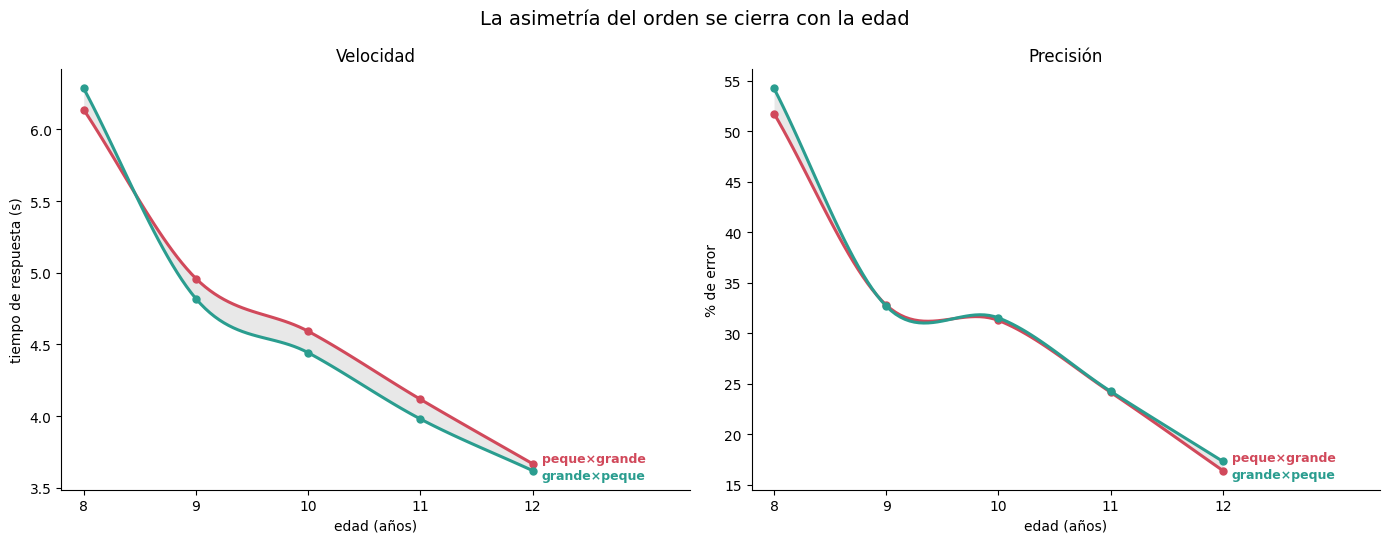

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("queries/asym_by_op_age.csv", thousands=",")
ab = df["operation"].str.extract(r"(\d+)X(\d+)").astype(int)
df["a"], df["b"] = ab[0], ab[1]
df = df[(df[["a","b"]].min(1) >= 2) & (df[["a","b"]].max(1) <= 9) & (df["a"] != df["b"])]
df["err"] = 100 * (1 - df["n_correct"] / df["n"])
key = df.set_index(["age", "a", "b"])
ages = sorted(df["age"].unique())

recs = []
for age in ages:
    for a in range(2, 10):
        for b in range(a + 1, 10):                         # a<b : petit×gran vs gran×petit
            if (age, a, b) in key.index and (age, b, a) in key.index:
                lo = key.loc[(age, a, b)]; hi = key.loc[(age, b, a)]
                recs.append((age, lo["median_rt"], hi["median_rt"], lo["err"], hi["err"]))
A = pd.DataFrame(recs, columns=["age", "rt_small", "rt_large", "err_small", "err_large"])
m = A.groupby("age").mean().reset_index()

def smooth(xv, yv, n=24):                                   # spline Catmull-Rom (sense scipy)
    xv = np.asarray(xv, float); yv = np.asarray(yv, float)
    X = np.r_[xv[0]-(xv[1]-xv[0]), xv, xv[-1]+(xv[-1]-xv[-2])]
    Y = np.r_[yv[0]-(yv[1]-yv[0]), yv, yv[-1]+(yv[-1]-yv[-2])]
    xs, ys = [], []
    for i in range(1, len(X)-2):
        p0, p1, p2, p3 = Y[i-1], Y[i], Y[i+1], Y[i+2]
        for t in np.linspace(0, 1, n, endpoint=False):
            ys.append(0.5*((2*p1)+(-p0+p2)*t+(2*p0-5*p1+4*p2-p3)*t*t+(-p0+3*p1-3*p2+p3)*t**3))
            xs.append(X[i]+(X[i+1]-X[i])*t)
    xs.append(X[-2]); ys.append(Y[-2]); return np.array(xs), np.array(ys)

c_small, c_large = "#d1495b", "#2a9d8f"
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
panels = [("rt_small", "rt_large", "tiempo de respuesta (s)", "Velocidad"),
          ("err_small", "err_large", "% de error", "Precisión")]
for ax, (cs, cl, ylab, title) in zip(axes, panels):
    xs, ys_s = smooth(m["age"], m[cs]); _, ys_l = smooth(m["age"], m[cl])
    ax.fill_between(xs, ys_s, ys_l, color="grey", alpha=.18, lw=0)
    ax.plot(xs, ys_s, color=c_small, lw=2.2); ax.plot(m["age"], m[cs], "o", color=c_small, ms=5)
    ax.plot(xs, ys_l, color=c_large, lw=2.2); ax.plot(m["age"], m[cl], "o", color=c_large, ms=5)
    # etiquetes separades si les línies conflueixen
    y_s, y_l = m[cs].iloc[-1], m[cl].iloc[-1]
    gap = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.04
    if abs(y_s - y_l) < gap:
        mid = (y_s + y_l) / 2; y_s, y_l = mid + gap/2, mid - gap/2
    ax.text(m["age"].iloc[-1]+.08, y_s, "peque×grande", color=c_small, va="center", fontsize=9, fontweight="bold")
    ax.text(m["age"].iloc[-1]+.08, y_l, "grande×peque", color=c_large, va="center", fontsize=9, fontweight="bold")
    ax.set_title(title, fontsize=12); ax.set_xlabel("edad (años)"); ax.set_ylabel(ylab)
    ax.set_xticks(ages); ax.set_xlim(ages[0]-.2, ages[-1]+1.4)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
fig.suptitle("La asimetría del orden se cierra con la edad", fontsize=14)
fig.tight_layout()
fig.savefig("plots/a998_commutative_convergence.png", dpi=200, bbox_inches="tight")
plt.show()